In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import matplotlib.colors as mcolors
import matplotlib as mpl
import seaborn as sns
import arviz as az
import colorsys

import sys
import os
import pickle
from tqdm import tqdm
# Get the absolute path to the folder containing `utils`
utils_path = os.path.abspath('../')
if utils_path not in sys.path:
    sys.path.append(utils_path)

os.environ["CUDA_VISIBLE_DEVICES"] = "2" # second gpu
# os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

from utils import *

az.style.use("arviz-doc")
plt.rcParams['figure.dpi'] = 140

from matplotlib import rc

rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial']})
rc('text', usetex=False)

experiment_orientations = [159, 123, 87, 51, 15]
subjects = ["01", "02", "03", "04", "05", "06", "07" ,"09", "10", "11", "12"]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

c_table = pd.read_csv('../data_caches/ctiraltable.csv')
med = np.load('../data_caches/med.npy')
std = np.load('../data_caches/std.npy')
ctimetable = np.load('../data_caches/ctimetable.npy')
r_table = pd.read_csv('../data_caches/rtrialtable.csv')
(x, y, d, r, e, cd, ce) = np.load('../data_caches/rtimetable.npy', allow_pickle=True)

In [3]:
import jax.numpy as jnp
import jax.random as jr
from jax import lax
from jax import vmap
import optax

from jax.extend import backend
print(backend.get_backend().platform)

gpu


In [4]:
def train_hmm(model, emissions, inputs, verbose = True):
    parameters, properties = model.initialize(key=jr.PRNGKey(1), method="prior", emissions = emissions)
    fit_params, lps = model.fit_em(params = parameters, props = properties, emissions = emissions, inputs = inputs, num_iters = 10,verbose = verbose)
    return model, fit_params, lps

def scale_to_bounds(x, axis=0, eps=1e-3):
    """
    Linearly rescales x along `axis` so that
      min → eps, max → 1-eps,
    and everything else is in between.
    """
    # compute min and max (keepdims so we can broadcast)
    mn = x.min(axis=axis, keepdims=True)
    mx = x.max(axis=axis, keepdims=True)
    # normalize to [0,1]
    x0 = (x - mn) / (mx - mn)
    # stretch to [eps, 1-eps]
    return x0 * (1 - 2*eps) + eps

## Data

In [5]:
# Modeling setup:
# emissions : 3 components -> reaction time, response angle, response error

# inputs for them:
# reaction time: error, surprise | attention, coherence, expectiation | bias
# response angle: stim, prev. stim, pre. resp | attention, coherence, expectation | bias
# response error: | attention, coherence, expectation | bias

# models for them:
# reaction time: Gamma GLM
# response angle: von Mises GLM
# response error: Beta GLM

In [7]:
# Fundamental input parameters
baseline_bias = np.ones((288, 120, 1))

coherence = (rdf.coh == "high").astype(np.float32).values.reshape(-1, 120, 1)
attention = (rdf.att == "focused").astype(np.float32).values.reshape(-1, 120, 1)
expectation = (rdf.exp_al == "expected").astype(np.float32).values.reshape(-1, 120, 1)

resp_err = np.deg2rad(rdf.resp_err.values.reshape(-1, 120, 1))
surprise = np.deg2rad((rdf.t_calib - rdf.exp).values.reshape(-1, 120, 1))
surprise = np.nan_to_num(surprise, nan=0.0)

stim = np.deg2rad(rdf.t_calib.values.reshape(-1, 120, 1))
prev_stim = np.deg2rad(rdf.prev_target.values.reshape(-1, 120, 1))
prev_resp = np.deg2rad(rdf.prev_resp.values.reshape(-1, 120, 1))

stim = ((stim + np.pi) % (2*np.pi)) - np.pi
prev_stim = ((prev_stim + np.pi) % (2*np.pi)) - np.pi
prev_resp = ((prev_resp + np.pi) % (2*np.pi)) - np.pi

# Emissions
# min max scale it using first axis - we are scaling each trial independently
# Reaction time: subtract baseline and convert to ms/frame
rt_raw = (r_table.f_resp.values - 250).reshape(-1, 120, 1) * (1000/120)
# reaction_time = scale_to_bounds(rt_raw, axis=0, eps=1e-3)
reaction_time = np.clip(rt_raw, 0.01, None)

# Response angle stays as radians (no scaling necessary)
# response_angle = np.deg2rad(r_table.resp.values).reshape(-1, 120, 1)
response_angle = np.deg2rad(r_table.resp.values).reshape(-1, 120, 1)
response_angle = ((response_angle + np.pi) % (2*np.pi)) - np.pi

# Response error: convert to radians then rescale into (eps,1-eps)
# err_raw = np.deg2rad(r_table.resp_err.values).reshape(-1, 120, 1)
# response_error = scale_to_bounds(err_raw, axis=0, eps=1e-3)
err_raw = r_table.resp_err.values.reshape(-1, 120, 1)
response_error = np.clip(err_raw, 0.01, None)


In [8]:

# print and check if any of these have nan in them
print("coherence", np.isnan(coherence).sum())
print("attention", np.isnan(attention).sum())
print("expectation", np.isnan(expectation).sum())

print("surprise", np.isnan(surprise).sum())
print("resp_err", np.isnan(resp_err).sum())

print("stim", np.isnan(stim).sum())
print("prev_stim", np.isnan(prev_stim).sum())
print("prev_resp", np.isnan(prev_resp).sum())

print("reaction_time", np.isnan(reaction_time).sum())
print("response_angle", np.isnan(response_angle).sum())
print("response_error", np.isnan(response_error).sum())

coherence 0
attention 0
expectation 0
surprise 0
resp_err 0
stim 0
prev_stim 0
prev_resp 0
reaction_time 0
response_angle 0
response_error 0


In [9]:
# lets package emissions and inputs
# reaction time: error, surprise | attention, coherence, expectiation | bias
# response angle: stim, prev. stim, pre. resp | attention, coherence, expectation | bias
# response error: | attention, coherence, expectation | bias

# exactly in this order
inputs = np.concatenate(
    (
        resp_err, surprise, attention, coherence, expectation, baseline_bias,
        stim, prev_stim, prev_resp, attention, coherence, expectation, baseline_bias,
        attention, coherence, expectation, baseline_bias
    ), 
    axis=-1
)

emissions = np.concatenate(
    (
        reaction_time, response_angle, response_error
    ), 
    axis=-1
)

emissions.shape, inputs.shape

((288, 120, 3), (288, 120, 17))

## Model comparisons

In [13]:
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [14]:
df = pd.DataFrame(
    {
        "Error": response_error.flatten(),
        "Surprise": surprise.flatten(),
        "Attention": attention.flatten(),
        "Coh": coherence.flatten(),
        "Exp": expectation.flatten(),
        "rt": reaction_time.flatten(),
    }
)

y = df['rt'].values
n = len(df)

results = []

# -- Unconditional fits --
# Gamma (no predictors)
a, loc, scale = stats.gamma.fit(y, floc=0)
ll = stats.gamma.logpdf(y, a, loc, scale).sum()
k = 2
aic = 2*k - 2*ll
bic = k * np.log(n) - 2*ll
results.append({'Model': 'Gamma (no predictors)', 'Params': k, 'AIC': aic, 'BIC': bic, 'Pseudo_R2': np.nan})

# Log-Normal (no predictors)
s, loc, scale = stats.lognorm.fit(y, floc=0)
ll = stats.lognorm.logpdf(y, s, loc, scale).sum()
k = 2
aic = 2*k - 2*ll
bic = k * np.log(n) - 2*ll
results.append({'Model': 'Lognormal (no predictors)', 'Params': k, 'AIC': aic, 'BIC': bic, 'Pseudo_R2': np.nan})

# -- Conditional GLMs --
formulas = [
    # E-only
    "rt ~ Error",
    "rt ~ Error + Attention + Coh + Exp",
    "rt ~ Error + Attention + Coh + Exp + Error:Attention + Error:Coh + Error:Exp",
    "rt ~ Error * (Attention + Coh + Exp)",

    # S-only
    "rt ~ Surprise",
    "rt ~ Surprise + Attention + Coh + Exp",
    "rt ~ Surprise + Attention + Coh + Exp + Surprise:Attention + Surprise:Coh + Surprise:Exp",
    "rt ~ Surprise * (Attention + Coh + Exp)",

    # E + S
    "rt ~ Error + Surprise",
    "rt ~ Error + Surprise + Attention + Coh + Exp",
    "rt ~ Error + Surprise + Attention + Coh + Exp + Error:Attention + Error:Coh + Error:Exp",
    "rt ~ Error + Surprise + Attention + Coh + Exp + Surprise:Attention + Surprise:Coh + Surprise:Exp",
    "rt ~ (Error + Surprise) * (Attention + Coh + Exp)",
    "rt ~ Error * Surprise * (Attention + Coh + Exp)"
]

for f in formulas:
    model = smf.glm(f, df, family=sm.families.Gamma(sm.families.links.Log())).fit()
    params = int(model.df_model) + 1
    aic = model.aic
    bic = model.bic_llf
    pseudo = model.pseudo_rsquared()
    results.append({'Model': f, 'Params': params, 'AIC': aic, 'BIC': bic, 'Pseudo_R2': pseudo})

df_res = pd.DataFrame(results)
df_res

,Model,Params,AIC,BIC,Pseudo_R2
0,Gamma (no predictors),2,536382.164043,536399.064947,NaN
1,Lognormal (no predictors),2,583722.436232,583739.337136,NaN
2,rt ~ Error,2,593218.405951,593235.306855,0.019493
3,rt ~ Error + Attention + Coh + Exp,5,594446.133381,594488.385642,0.032763
4,rt ~ Error + Attention + Coh + Exp + Error:Att...,8,594013.364019,594080.967637,0.038127
5,rt ~ Error * (Attention + Coh + Exp),8,594013.364019,594080.967637,0.038127
6,rt ~ Surprise,2,596334.394928,596351.295832,0.000255
7,rt ~ Surprise + Attention + Coh + Exp,5,597550.315294,597592.567555,0.008669
8,rt ~ Surprise + Attention + Coh + Exp + Surpri...,7,597535.441368,597594.594533,0.008815
9,rt ~ Surprise * (Attention + Coh + Exp),7,597535.441368,597594.594533,0.008815


In [15]:
best_rt_model = smf.glm("rt ~ Error * (Attention + Coh + Exp)", df, family=sm.families.Gamma(sm.families.links.Log())).fit()
print(best_rt_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                     rt   No. Observations:                34560
Model:                            GLM   Df Residuals:                    34552
Model Family:                   Gamma   Df Model:                            7
Link Function:                    Log   Scale:                         0.25620
Method:                          IRLS   Log-Likelihood:            -2.9700e+05
Date:                Fri, 16 May 2025   Deviance:                       37584.
Time:                        04:13:58   Pearson chi2:                 8.85e+03
No. Iterations:                    13   Pseudo R-squ. (CS):            0.03813
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           6.8695      0.009    8

In [16]:
df_err = pd.DataFrame(
    {
        "rt": reaction_time.flatten(),
        "Attention": attention.flatten(),
        "Coh": coherence.flatten(),
        "Exp": expectation.flatten(),
        "error": response_error.flatten(),
    }
)

# -- Conditional GLMs for the Error Model (Gamma, log-link) --
formulas = [
    "error ~ rt",
    "error ~ rt + Attention + Coh + Exp",
    "error ~ rt * (Attention + Coh + Exp)"
]

results = []
for f in formulas:
    m = smf.glm(f, df_err, family=sm.families.Gamma(sm.families.links.Log())).fit()
    results.append({
        'Model':       f,
        'Params':      int(m.df_model) + 1,
        'AIC':         m.aic,
        'BIC':         m.bic_llf,
        'Pseudo_R2':   m.pseudo_rsquared(),
    })
df_res = pd.DataFrame(results)
df_res


,Model,Params,AIC,BIC,Pseudo_R2
0,error ~ rt,2,324998.987428,325015.888332,0.016319
1,error ~ rt + Attention + Coh + Exp,5,323696.658707,323738.910968,0.042010
2,error ~ rt * (Attention + Coh + Exp),8,323345.521266,323413.124884,0.047781


In [17]:
best_err_model = smf.glm("error ~ rt * (Attention + Coh + Exp)", df_err, family=sm.families.Gamma(sm.families.links.Log())).fit()
print(best_err_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  error   No. Observations:                34560
Model:                            GLM   Df Residuals:                    34552
Model Family:                   Gamma   Df Model:                            7
Link Function:                    Log   Scale:                          1.0518
Method:                          IRLS   Log-Likelihood:            -1.6166e+05
Date:                Fri, 16 May 2025   Deviance:                       51333.
Time:                        04:13:59   Pearson chi2:                 3.63e+04
No. Iterations:                    25   Pseudo R-squ. (CS):            0.04778
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.9986      0.026    153.614   

In [ ]:
import patsy
import pymc as pm
import arviz as az

df_resp = pd.DataFrame(
    {
        "stim": stim.flatten(),
        "prev_stim": prev_stim.flatten(),
        "prev_resp": prev_resp.flatten(),
        "Attention": attention.flatten(),
        "Coh": coherence.flatten(),
        "Exp": expectation.flatten(),
        "angle_wrapped": response_angle.flatten(),
    }
)

# 2) Define your formulas
formulas = [
    "1 + stim",
    "1 + stim + prev_stim",
    "1 + stim + prev_stim + prev_resp",
    "1 + prev_stim + prev_resp + stim*(Attention + Coh + Exp)"
]

single_results = []
mix_weight_results = []
full_mix_results = []
n = df_resp.shape[0]

def max_loglike(idata, var_name):
    # grab the DataArray of log_likelihood for that RV
    ll = idata.log_likelihood[var_name]
    # find the “obs” dimension (the one that’s not chain/draw)
    obs_dim = [d for d in ll.dims if d not in ("chain","draw")][0]
    # sum over observations, then take the max over all chains & draws
    ll_sum   = ll.sum(dim=obs_dim)
    max_ll   = ll_sum.max(dim=("chain","draw")).values
    return max_ll

for formula in formulas:
    # 1) Build design
    y, X = patsy.dmatrices(f"angle_wrapped ~ {formula}", df_resp, return_type="dataframe")
    X_mat, y_vec = X.values, y.values.flatten()
    
    # 2) Single VM
    with pm.Model() as vm1:
        β   = pm.Normal("β", 0, 5, shape=X_mat.shape[1])
        κ   = pm.HalfNormal("κ", 2)
        μ   = pm.math.dot(X_mat, β)
        RA  = pm.VonMises("RA", mu=μ, kappa=κ, observed=y_vec)
        id1 = pm.sample(1000, tune=1000, cores=2,
                        return_inferencedata=True,
                        idata_kwargs={"log_likelihood": True},
                        target_accept=0.9)
    max_ll1 = max_loglike(id1, "RA")
    k1      = X_mat.shape[1] + 1
    AIC1    = 2*k1 - 2*max_ll1
    BIC1    = k1*np.log(n) - 2*max_ll1
    
    single_results.append({
        "formula":      formula,
        "k":            k1,
        "AIC":          AIC1,
        "BIC":          BIC1,
    })

for formula in formulas:
    # 1) Build design
    y, X = patsy.dmatrices(f"angle_wrapped ~ {formula}", df_resp, return_type="dataframe")
    X_mat, y_vec = X.values, y.values.flatten()
    
    # 3) 2-component VM mixture
    with pm.Model() as vm2:
        β    = pm.Normal("β", 0, 5, shape=X_mat.shape[1])
        κ1   = pm.HalfNormal("κ1", 2)
        κ2   = pm.HalfNormal("κ2", 2)
        w    = pm.Dirichlet("w", a=np.ones(2))
        μ    = pm.math.dot(X_mat, β)
        comp1= pm.VonMises.dist(mu=μ, kappa=κ1)
        comp2= pm.VonMises.dist(mu=μ, kappa=κ2)
        RA2  = pm.Mixture("RA_mix", w, [comp1, comp2], observed=y_vec)
        id2 = pm.sample(1000, tune=1000, cores=2,
                        return_inferencedata=True,
                        idata_kwargs={"log_likelihood": True},
                        target_accept=0.9)
        max_ll2 = max_loglike(id2, "RA_mix")
    max_ll2 = max_loglike(id2, "RA_mix")
    k2      = X_mat.shape[1] + 3
    AIC2    = 2*k2 - 2*max_ll2
    BIC2    = k2*np.log(n) - 2*max_ll2

    mix_weight_results.append({
        "formula":      formula,
        "k":            k2,
        "AIC":          AIC2,
        "BIC":          BIC2,
    })

for formula in formulas:
    # 1) Build design
    y, X = patsy.dmatrices(f"angle_wrapped ~ {formula}", df_resp, return_type="dataframe")
    X_mat, y_vec = X.values, y.values.flatten()
    
    # 3) 2-component VM mixture
    with pm.Model() as vm3:
        β1    = pm.Normal("β1", 0, 5, shape=X_mat.shape[1])
        β2    = pm.Normal("β2", 0, 5, shape=X_mat.shape[1])
        κ1   = pm.HalfNormal("κ1", 2)
        κ2   = pm.HalfNormal("κ2", 2)
        w    = pm.Dirichlet("w", a=np.ones(2))
        μ1    = pm.math.dot(X_mat, β1)
        μ2    = pm.math.dot(X_mat, β2)
        comp1= pm.VonMises.dist(mu=μ1, kappa=κ1)
        comp2= pm.VonMises.dist(mu=μ2, kappa=κ2)
        RA3  = pm.Mixture("RA_mix", w, [comp1, comp2], observed=y_vec)
        id3 = pm.sample(1000, tune=1000, cores=2,
                        return_inferencedata=True,
                        idata_kwargs={"log_likelihood": True},
                        target_accept=0.9)
        max_ll3 = max_loglike(id3, "RA_mix")
    max_ll3 = max_loglike(id3, "RA_mix")
    k3      = 2*X_mat.shape[1] + 3
    AIC3    = 2*k3 - 2*max_ll3
    BIC3    = k3*np.log(n) - 2*max_ll3

    full_mix_results.append({
        "formula":      formula,
        "k":            k3,
        "AIC":          AIC3,
        "BIC":          BIC3,
    })
df_single = pd.DataFrame(single_results)
df_mix_weight = pd.DataFrame(mix_weight_results)
df_full_mix = pd.DataFrame(full_mix_results)

In [49]:
df_single

,formula,k,AIC,BIC
0,1 + stim,3,82564.937113,82590.288470
1,1 + stim + prev_stim,4,82566.369324,82600.171132
2,1 + stim + prev_stim + prev_resp,5,82518.795657,82561.047918
3,1 + prev_stim + prev_resp + stim*(Attention + ...,11,81687.022650,81779.977625


In [50]:
df_mix_weight

,formula,k,AIC,BIC
0,1 + stim,5,82568.963183,82611.215444
1,1 + stim + prev_stim,6,82570.504955,82621.207668
2,1 + stim + prev_stim + prev_resp,7,82522.740432,82581.893598
3,1 + prev_stim + prev_resp + stim*(Attention + ...,13,81692.787374,81802.643253


In [1]:
df_full_mix

NameError: name 'df_full_mix' is not defined

In [19]:
# Best RA model     

y, X = patsy.dmatrices(f"angle_wrapped ~ 1 + stim + prev_stim + prev_resp + Attention + Coh + Exp", df_resp, return_type="dataframe")
X_mat, y_vec = X.values, y.values.flatten()

# 3) 2-component VM mixture
with pm.Model() as vm3:
    β1    = pm.Normal("β1", 0, 5, shape=X_mat.shape[1])
    β2    = pm.Normal("β2", 0, 5, shape=X_mat.shape[1])
    κ1   = pm.HalfNormal("κ1", 2)
    κ2   = pm.HalfNormal("κ2", 2)
    w    = pm.Dirichlet("w", a=np.ones(2))
    μ1    = pm.math.dot(X_mat, β1)
    μ2    = pm.math.dot(X_mat, β2)
    comp1= pm.VonMises.dist(mu=μ1, kappa=κ1)
    comp2= pm.VonMises.dist(mu=μ2, kappa=κ2)
    RA3  = pm.Mixture("RA_mix", w, [comp1, comp2], observed=y_vec)
    id3 = pm.sample(1000, tune=1000, cores=2,
                    return_inferencedata=True,
                    idata_kwargs={"log_likelihood": True},
                    target_accept=0.9)
    max_ll3 = max_loglike(id3, "RA_mix")
max_ll3 = max_loglike(id3, "RA_mix")
k3      = 2*X_mat.shape[1] + 3
AIC3    = 2*k3 - 2*max_ll3
BIC3    = k3*np.log(n) - 2*max_ll3

print({
    "formula":      "angle_wrapped ~ 1 + stim + prev_stim + prev_resp + Attention + Coh + Exp",
    "k":            k3,
    "AIC":          AIC3,
    "BIC":          BIC3,
})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [β1, β2, κ1, κ2, w]
/home/nuttidalab/miniconda3/envs/ssm/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/home/nuttidalab/miniconda3/envs/ssm/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 172 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


{'formula': 'angle_wrapped ~ 1 + stim + prev_stim + prev_resp + Attention + Coh + Exp', 'k': 17, 'AIC': 68011.58482206984, 'BIC': 68155.24250985944}


array([[<Axes: title={'center': 'w'}>, <Axes: title={'center': 'w'}>],
       [<Axes: title={'center': 'β1'}>, <Axes: title={'center': 'β1'}>],
       [<Axes: title={'center': 'β2'}>, <Axes: title={'center': 'β2'}>],
       [<Axes: title={'center': 'κ1'}>, <Axes: title={'center': 'κ1'}>],
       [<Axes: title={'center': 'κ2'}>, <Axes: title={'center': 'κ2'}>]],
      dtype=object)

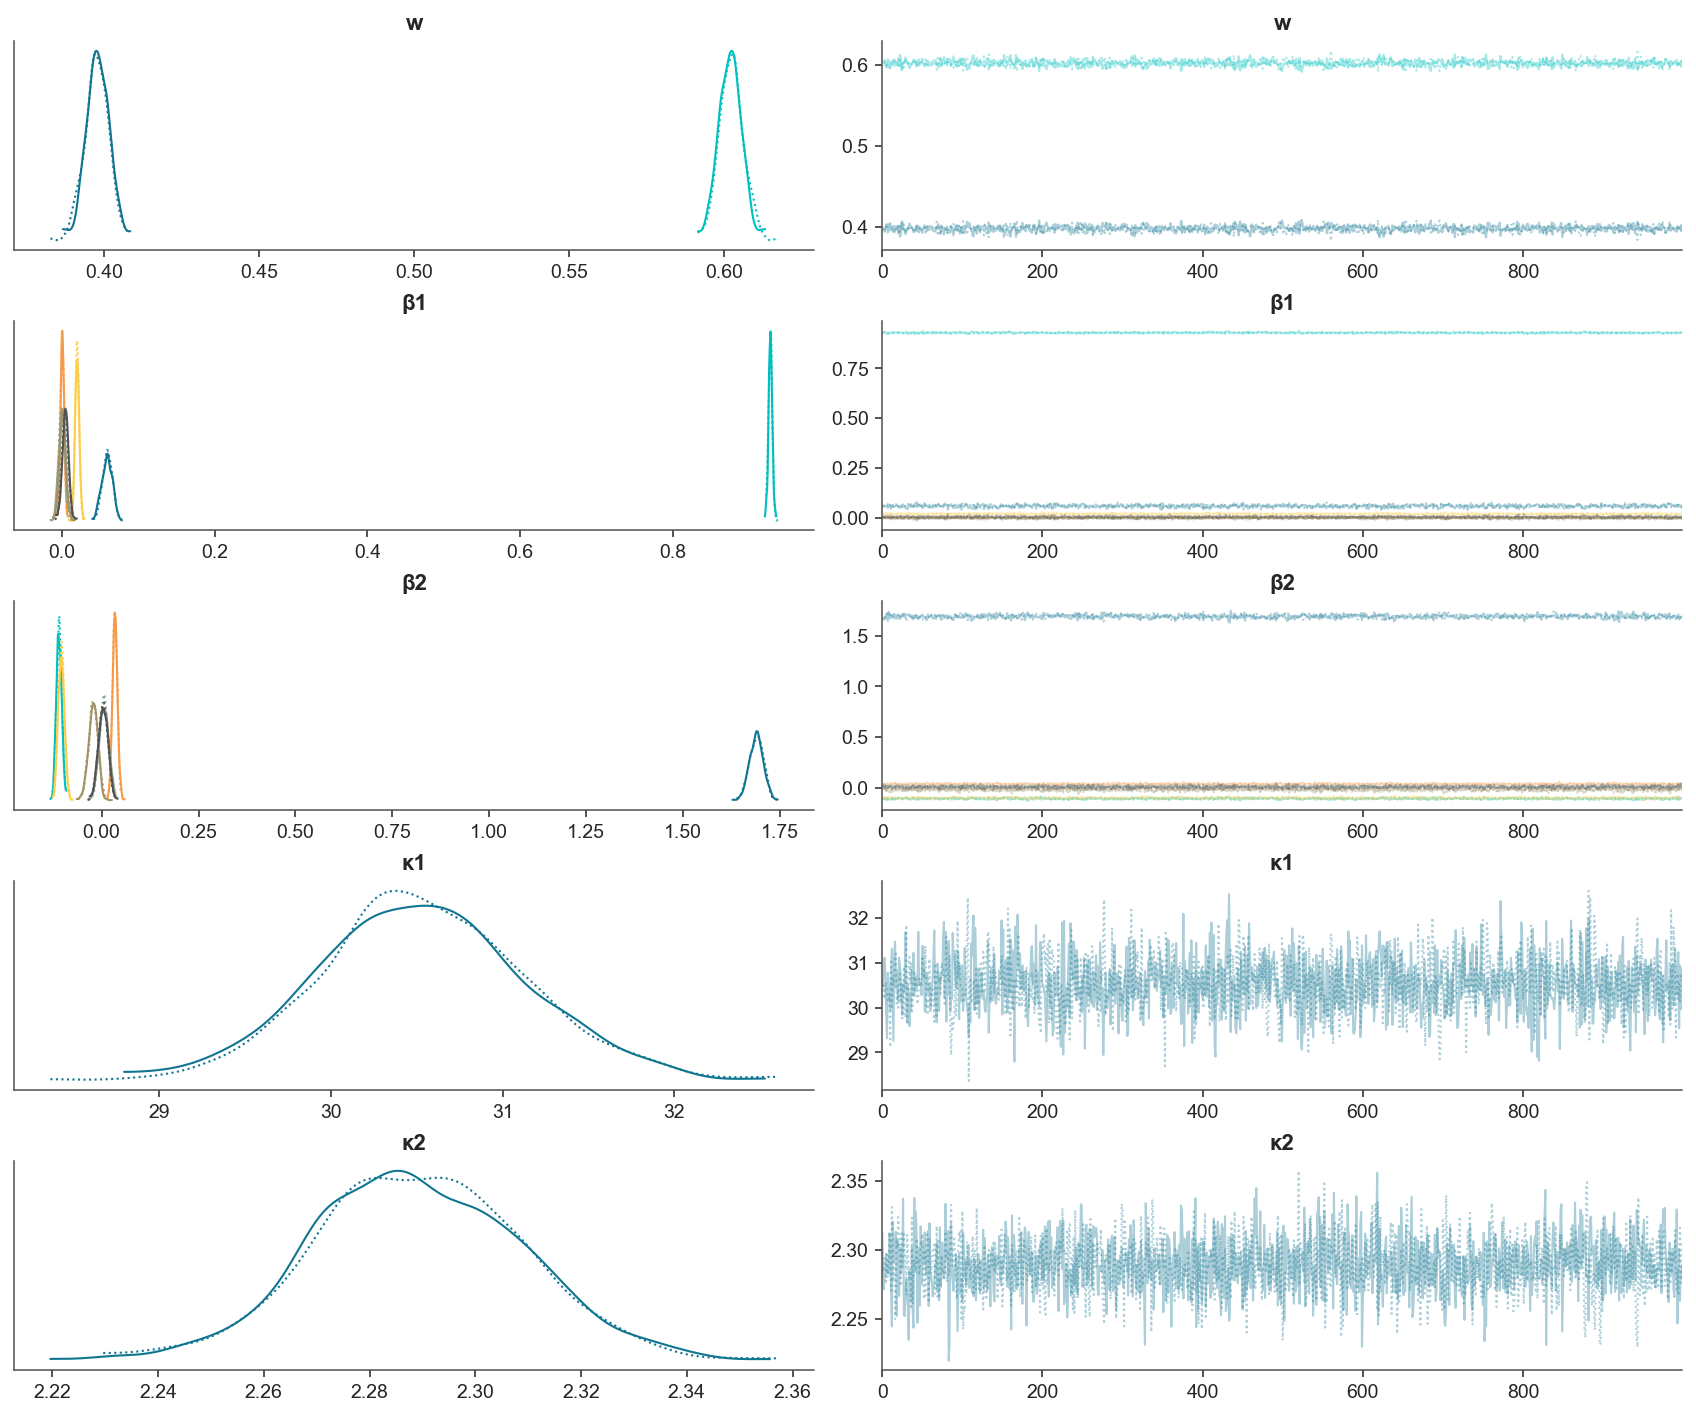

In [20]:
az.plot_trace(id3)

In [22]:
summary = az.summary(id3, hdi_prob=0.95)
print(summary)

         mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
w[0]    0.398  0.004     0.390      0.405      0.000     0.00    1455.0   
w[1]    0.602  0.004     0.595      0.610      0.000     0.00    1455.0   
β1[0]   0.059  0.007     0.046      0.071      0.000     0.00    1171.0   
β1[1]   0.928  0.002     0.923      0.933      0.000     0.00    1478.0   
β1[2]   0.000  0.002    -0.004      0.005      0.000     0.00    1944.0   
β1[3]   0.020  0.003     0.015      0.025      0.000     0.00    2215.0   
β1[4]  -0.000  0.004    -0.008      0.007      0.000     0.00    1733.0   
β1[5]   0.001  0.004    -0.008      0.009      0.000     0.00    1894.0   
β1[6]   0.004  0.004    -0.004      0.012      0.000     0.00    2241.0   
β2[0]   1.689  0.018     1.656      1.725      0.001     0.00    1242.0   
β2[1]  -0.110  0.007    -0.122     -0.097      0.000     0.00    1341.0   
β2[2]   0.034  0.006     0.022      0.047      0.000     0.00    2120.0   
β2[3]  -0.104  0.008    -

In [44]:
posterior = id3.posterior  # dims chain x draw x parameter_dim
# flatten chain+draw into one axis:
flat = posterior.stack(samples=("chain","draw"))

pvals = {}
for var in flat.data_vars:
    samples = flat[var].values.flatten()
    p_above = (samples > 0).mean()    # P(β>0)
    p_below = (samples < 0).mean()    # P(β<0)
    pvals[var] = {"P(>0)": p_above, "P(<0)": p_below}

print(pd.DataFrame(pvals).T)

      P(>0)    P(<0)
w   1.00000  0.00000
β1  0.56970  0.43030
β2  0.51625  0.48375
κ1  1.00000  0.00000
κ2  1.00000  0.00000


# HMM VIZ

## Result visualisations

In [12]:
with open('./caches/global_params.pkl', 'rb') as f:
    global_params = pickle.load(f)

with open('./caches/global_crossval.pkl', 'rb') as f:
    global_crossval = pickle.load(f)

with open('./caches/sub_crossval_results.pkl', 'rb') as f:
    crossval_results = pickle.load(f)

with open('./caches/subject_params.pkl', 'rb') as f:
    subject_params = pickle.load(f)

with open('./caches/one_state_crossval_result.pkl', 'rb') as f:
    ost_crossval = pickle.load(f)

# with open('./caches/cond_params.pkl', 'rb') as f:
#     cond_params = pickle.load(f)

with open('./caches/ml_states.pkl', 'rb') as f:
    ml_states = pickle.load(f)

In [13]:
num_states, input_dim, emission_dim = 2, 17, 3

## Crossval visualisation

In [14]:
full_crossval = crossval_results.copy()
for idx in range(12):
    full_crossval[idx][1] = ost_crossval[idx][1]

### AIC BIC viz

In [15]:
all_cv = []
all_ll = []

for idx in range(12):
    sb = []
    ll = []
    for nstate in range(1,10):
        sb.append(crossval_results[idx][nstate].mean())
        ll.append(crossval_results[idx][nstate])
    all_cv.append(sb)
    all_ll.append(ll)

all_cv = np.array(all_cv)
all_ll = np.array(all_ll)

In [16]:
all_aic, all_bic = [], []
for idx, subjects in enumerate(all_ll):
    aic, bic = [], []
    for i, (n_state, ll) in enumerate(zip(np.arange(1,10), subjects)):
        a, b = calc_aic_bic_vhmm(n_state = n_state, log_likelihood = ll, input_dim = input_dim, output_dim = emission_dim, T = 120)
        # print(f"Model with {n_state} states has AIC: {aic} and BIC: {bic}")
        aic.append(a)
        bic.append(b)
    all_aic.append(aic)
    all_bic.append(bic)
all_aic, all_bic = np.array(all_aic), np.array(all_bic)

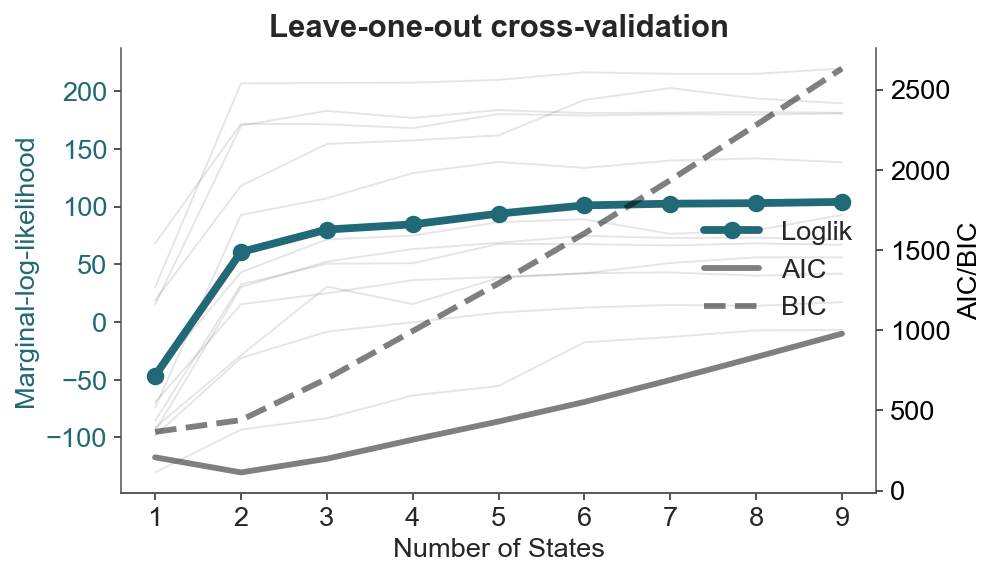

In [19]:
fig, ax1 = plt.subplots(figsize=(7, 4))

# Plot each individual log-likelihood curve on ax1 (left axis)
for subjects in all_cv:
    ax1.plot(np.arange(1, 10), subjects, "-k", alpha=0.1, linewidth=1)

# Plot the mean log-likelihood on ax1 in green
ax1.plot(np.arange(1, 10), np.array(all_cv).mean(axis=0), "-o", color="#216976",
         alpha=1, label="Loglik", linewidth=4, markersize=8)
ax1.set_xlabel("Number of States")
ax1.set_ylabel("Marginal-log-likelihood", color="#216976")
ax1.tick_params(axis='y', labelcolor="#216976")
ax1.set_xticks(np.arange(1, 10))
ax1.set_title("Leave-one-out cross-validation")

# Create a second y-axis sharing the same x-axis for AIC/BIC
ax2 = ax1.twinx()
ax2.plot(np.arange(1, 10), np.array(all_aic).mean(axis=(0,2)), "-k", 
         alpha=0.5, label="AIC", linewidth=3, markersize=5)
ax2.plot(np.arange(1, 10), np.array(all_bic).mean(axis=(0,2)), "--k", 
         alpha=0.5, label="BIC", linewidth=3, markersize=5)
ax2.set_ylabel("AIC/BIC", color="k")
ax2.tick_params(axis='y', labelcolor="k")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', frameon=False)

# Axis border off
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(True)
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)

plt.show()
# plt.savefig("mloocv.svg", format="svg", transparent=True)

Text(0.5, 0.98, 'LOOCV')

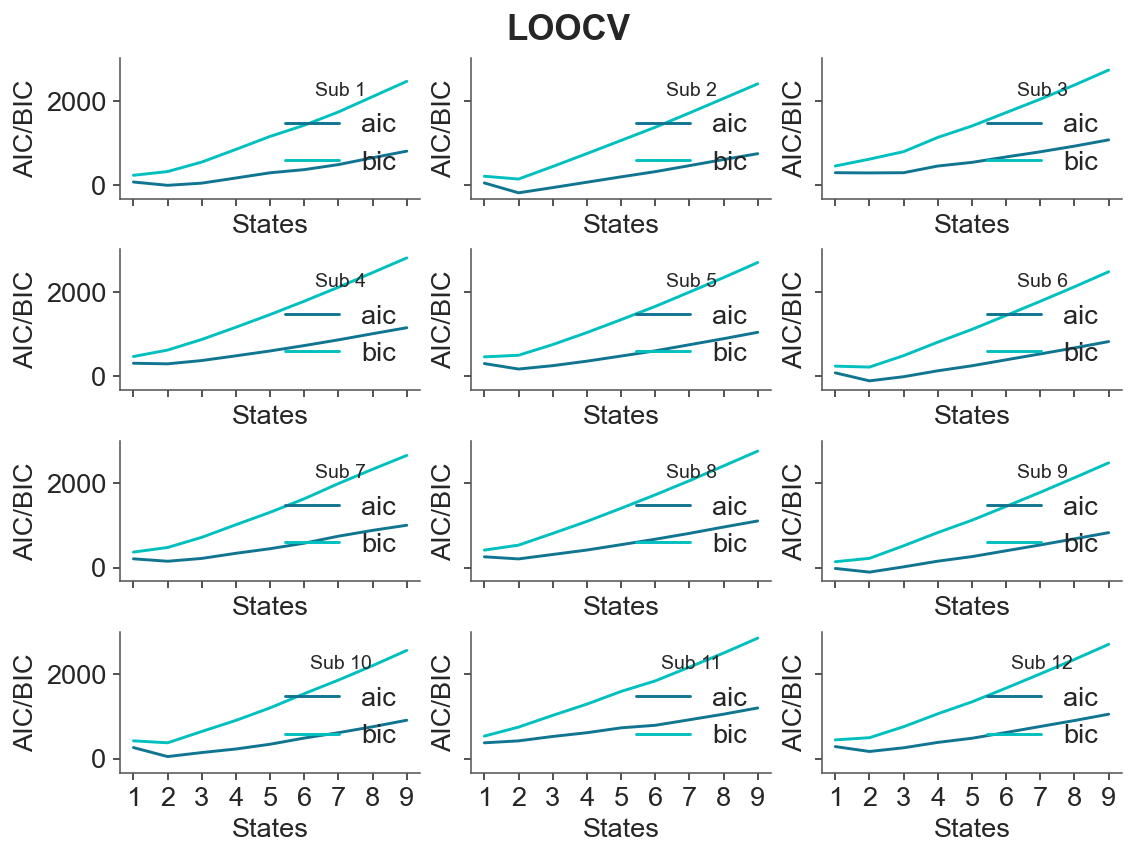

In [20]:
fig, ax = plt.subplots(4, 3, figsize=(8, 6), sharex=True, sharey=True)
ax = ax.flatten()

# for idx, subjects in enumerate(all_ll):
#     for x in np.arange(1, 10):
#         ax[idx].scatter([x] * len(subjects[x-2]), subjects[x-2],s=5, alpha=1, color="lightgray")

for idx, (aic, bic) in enumerate(zip(all_aic, all_bic)):
    # plt.plot(np.arange(1, 10), subjects, "-k.", alpha=0.5)
    ax[idx].plot(np.arange(1, 10), aic.mean(axis=1), alpha=1, label=f"aic")
    ax[idx].plot(np.arange(1, 10), bic.mean(axis=1), alpha=1, label=f"bic")
    
    ax[idx].legend(frameon=False, loc="lower right", title = f"Sub {idx+1}")
    ax[idx].set_xticks(np.arange(1, 10))
    
    ax[idx].set_ylabel("AIC/BIC")
    ax[idx].set_xlabel("States")

plt.suptitle("LOOCV")

# plt.tight_layout()

## Params viz

In [21]:
def adjust_color_hls(color, factor=1.0):
    """
    Lighten or darken a color while maintaining its hue and saturation.
    Args:
        color (str or tuple): Base color in any Matplotlib-compatible format.
        factor (float): Factor by which to adjust the lightness. >1 darkens, <1 lightens.
    Returns:
        tuple: Adjusted color in RGBA format.
    """
    # Convert the color to RGB and then to HLS
    rgb = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(*rgb)
    
    # Adjust the lightness
    l = max(0, min(1, l * factor))
    
    # Convert back to RGB
    adjusted_rgb = colorsys.hls_to_rgb(h, l, s)
    return adjusted_rgb

# Example usage
# light_orange = adjust_color_hls("orange", factor=1.4)  # Lighter orange
# dark_orange = adjust_color_hls("orange", factor=1)   # Darker orange

# light_blue = adjust_color_hls("blue", factor=1.4)  # Lighter blue
# dark_blue = adjust_color_hls("blue", factor=1)   # Darker blue

light_orange = "lightgray"
dark_orange = "gray"

light_blue = "#216976"
dark_blue = "#0e2d33"

# light_cols = [light_blue, light_orange]
# dark_cols = [dark_blue, dark_orange]
light_cols = ["#216976", "gray"] # salmon, purp
dark_cols = ["#0e2d33", "lightgray"]

# light_cols = ["#fe7070", "#9391ff"] # salmon, purp
# dark_cols = ["#b34f4f", "#6766b3"]

#9391ff - purp
#6766b3 - dark purp

#fe7070 - salmon
#b34f4f - dark salmon


## Subject params viz

In [95]:
weights_rt = []
alpha_rt = []
weights_ra = []
kappa_ra = []
weights_re = []
phi_re = []
transitions = []

for i in range(12):
    weights_rt.append(subject_params[i][2].emissions.weights_rt)
    alpha_rt.append(subject_params[i][2].emissions.alpha_rt)
    weights_ra.append(subject_params[i][2].emissions.weights_ra)
    kappa_ra.append(subject_params[i][2].emissions.kappa_ra)
    weights_re.append(subject_params[i][2].emissions.weights_re)
    phi_re.append(subject_params[i][2].emissions.phi_re)
    transitions.append(subject_params[i][2].transitions.transition_matrix)

weights_rt = np.array(weights_rt)
alpha_rt = np.array(alpha_rt)
weights_ra = np.array(weights_ra)
kappa_ra = np.array(kappa_ra)
weights_re = np.array(weights_re)
phi_re = np.array(phi_re)
transitions = np.array(transitions)

In [96]:
# Rt : # error, surprise | attention, coherence, expectiation | bias
# Ra : # stim, prev. stim, pre. resp | attention, coherence, expectation | bias
# Re : # | attention, coherence, expectation | bias

In [97]:
# take the weights for attention, coherence, expectiation out from everywhere and make a 3 bar plot

# reaction time
rt_fixed = weights_rt[:, :, 2:5]
ra_fixed = weights_ra[:, :, 3:6]
re_fixed = weights_re[:, :, 0:3]

rt_bias = weights_rt[:, :, 5]
ra_bias = weights_ra[:, :, 6]
re_bias = weights_re[:, :, 3]

rt_error = weights_rt[:, :, 0]
rt_surprise = weights_rt[:, :, 1]

ra_stim = weights_ra[:, :, 0]
ra_prev_stim = weights_ra[:, :, 1]
ra_prev_resp = weights_ra[:, :, 2]

In [98]:
# listed cmap from red to blue discrete, 12 of them
cmap = sns.color_palette("rocket", 12)
cmap

[(0.1125315, 0.06742194, 0.17414848),
 (0.22741085, 0.10140876, 0.25340813),
 (0.34940101, 0.11863987, 0.3138355),
 (0.47114798, 0.12098721, 0.34787978),
 (0.60444226, 0.10573912, 0.35820487),
 (0.73669146, 0.08704683, 0.33543669),
 (0.84335441, 0.14556683, 0.28480819),
 (0.91978131, 0.27526191, 0.24245973),
 (0.95001704, 0.42771398, 0.29244728),
 (0.96077819, 0.55997184, 0.39941173),
 (0.96479861, 0.68910113, 0.53756026),
 (0.9698028, 0.80981139, 0.70252255)]

In [99]:
# order of performance
perf_order = np.array([8,1,5,9,4,11,7,3,2,6,0,10])
# reorder the cmap
perf_cmap = [cmap[i] for i in perf_order]

/tmp/ipykernel_524200/3366608687.py:78: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


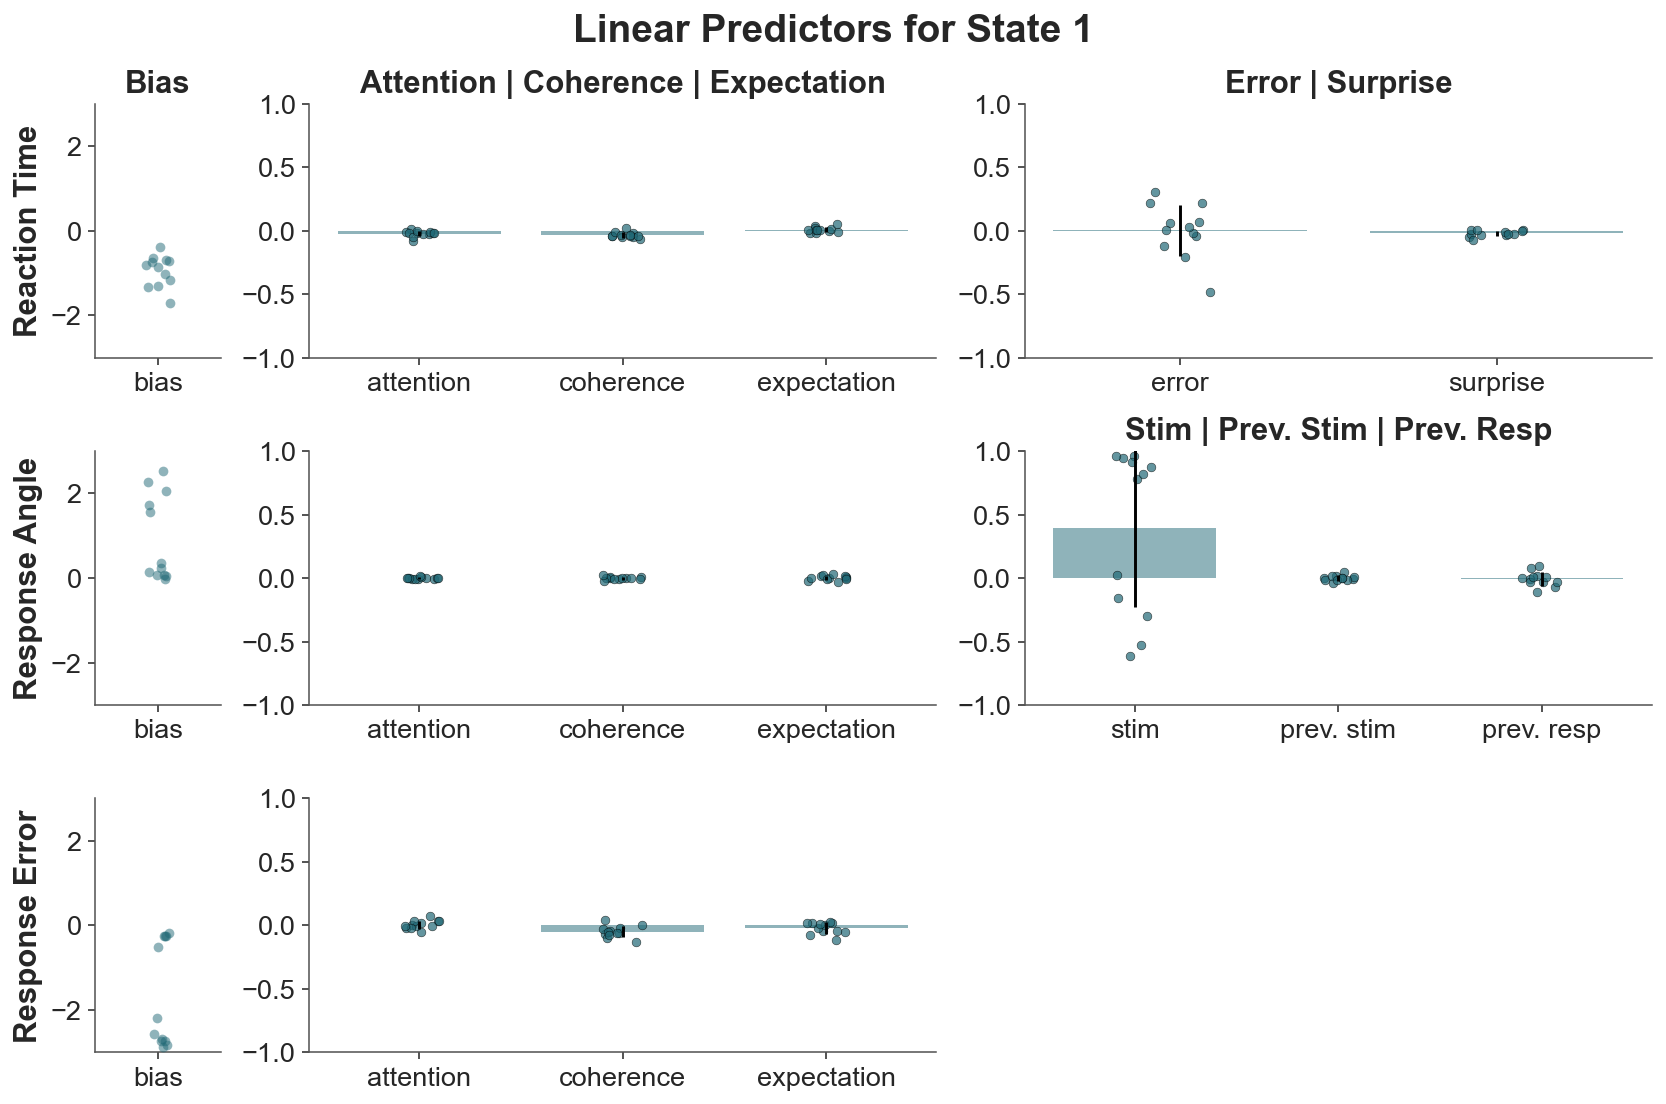

In [102]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

state = 1
jitter_width = 0.1

# data containers
bias_data   = [rt_bias,    ra_bias,    re_bias]
fixed_data  = [rt_fixed,   ra_fixed,   re_fixed]
fixed_labels = ["attention", "coherence", "expectation"]

var_defs = [
    (["error", "surprise"],              [rt_error,    rt_surprise]),
    (["stim", "prev. stim", "prev. resp"], [ra_stim, ra_prev_stim, ra_prev_resp]),
    (None,                                  None),
]

ylabels = ["Reaction Time", "Response Angle", "Response Error"]

fig, ax = plt.subplots(3, 3, figsize=(12, 8), sharey=False, width_ratios=[0.2, 1, 1])


for i in range(3):
    # 1) bias stripplot
    sns.stripplot(
        x=["bias"] * bias_data[i].shape[0],
        y=bias_data[i][:, state],
        color=light_blue, alpha=0.5,
        size=5, jitter=True,
        ax=ax[i, 0]
    )
    ax[i, 0].set_ylabel(ylabels[i], fontsize=16, fontweight="bold")
    ax[i, 0].set_ylim(-3, 3)
    

    # 2) fixed‑features bar + scatter
    means = fixed_data[i][:, state].mean(axis=0)
    stds  = fixed_data[i][:, state].std(axis=0)
    ax[i, 1].bar(fixed_labels, means, yerr=stds, color=light_blue, alpha=0.5)
    # scatter raw points
    for j, _ in enumerate(fixed_labels):
        vals   = fixed_data[i][:, state, j]
        jitter = np.random.uniform(-jitter_width, jitter_width, size=vals.shape)
        ax[i, 1].scatter(
            j + jitter, vals,
            color=light_blue, alpha=0.7,
            s=20, edgecolor='k', linewidth=0.3
        )
        ax[i, 1].set_ylim(-1, 1)

    # 3) variable‑features bar + scatter (or hide)
    labels, arrays = var_defs[i]
    if labels is None:
        ax[i, 2].set_visible(False)
    else:
        means = [arr[:, state].mean() for arr in arrays]
        stds  = [arr[:, state].std()  for arr in arrays]
        ax[i, 2].bar(labels, means, yerr=stds, color=light_blue, alpha=0.5)
        for j, arr in enumerate(arrays):
            vals   = arr[:, state]
            jitter = np.random.uniform(-jitter_width, jitter_width, size=vals.shape)
            ax[i, 2].scatter(
                j + jitter, vals,
                color=light_blue, alpha=0.7,
                s=20, edgecolor='k', linewidth=0.3
            )
            ax[i, 2].set_ylim(-1, 1)

# column titles
ax[0, 0].set_title("Bias")
ax[0, 1].set_title("Attention | Coherence | Expectation")
ax[0, 2].set_title("Error | Surprise")
ax[1, 2].set_title("Stim | Prev. Stim | Prev. Resp")

plt.suptitle(f"Linear Predictors for State {state}", fontsize=20, fontweight="bold")

plt.tight_layout()
plt.show()


## Global params viz

In [81]:
weights_rt = []
alpha_rt = []
weights_ra = []
kappa_ra = []
weights_re = []
phi_re = []
transitions = []


weights_rt.append(global_params[2].emissions.weights_rt)
alpha_rt.append(global_params[2].emissions.alpha_rt)
weights_ra.append(global_params[2].emissions.weights_ra)
kappa_ra.append(global_params[2].emissions.kappa_ra)
weights_re.append(global_params[2].emissions.weights_re)
phi_re.append(global_params[2].emissions.phi_re)
transitions.append(global_params[2].transitions.transition_matrix)

weights_rt = np.array(weights_rt)
alpha_rt = np.array(alpha_rt)
weights_ra = np.array(weights_ra)
kappa_ra = np.array(kappa_ra)
weights_re = np.array(weights_re)
phi_re = np.array(phi_re)
transitions = np.array(transitions)

In [82]:
# take the weights for attention, coherence, expectiation out from everywhere and make a 3 bar plot

# reaction time
rt_fixed = weights_rt[:, :, 2:5]
ra_fixed = weights_ra[:, :, 3:6]
re_fixed = weights_re[:, :, 0:3]

rt_bias = weights_rt[:, :, 5]
ra_bias = weights_ra[:, :, 6]
re_bias = weights_re[:, :, 3]

rt_error = weights_rt[:, :, 0]
rt_surprise = weights_rt[:, :, 1]

ra_stim = weights_ra[:, :, 0]
ra_prev_stim = weights_ra[:, :, 1]
ra_prev_resp = weights_ra[:, :, 2]

/tmp/ipykernel_524200/2887008932.py:78: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


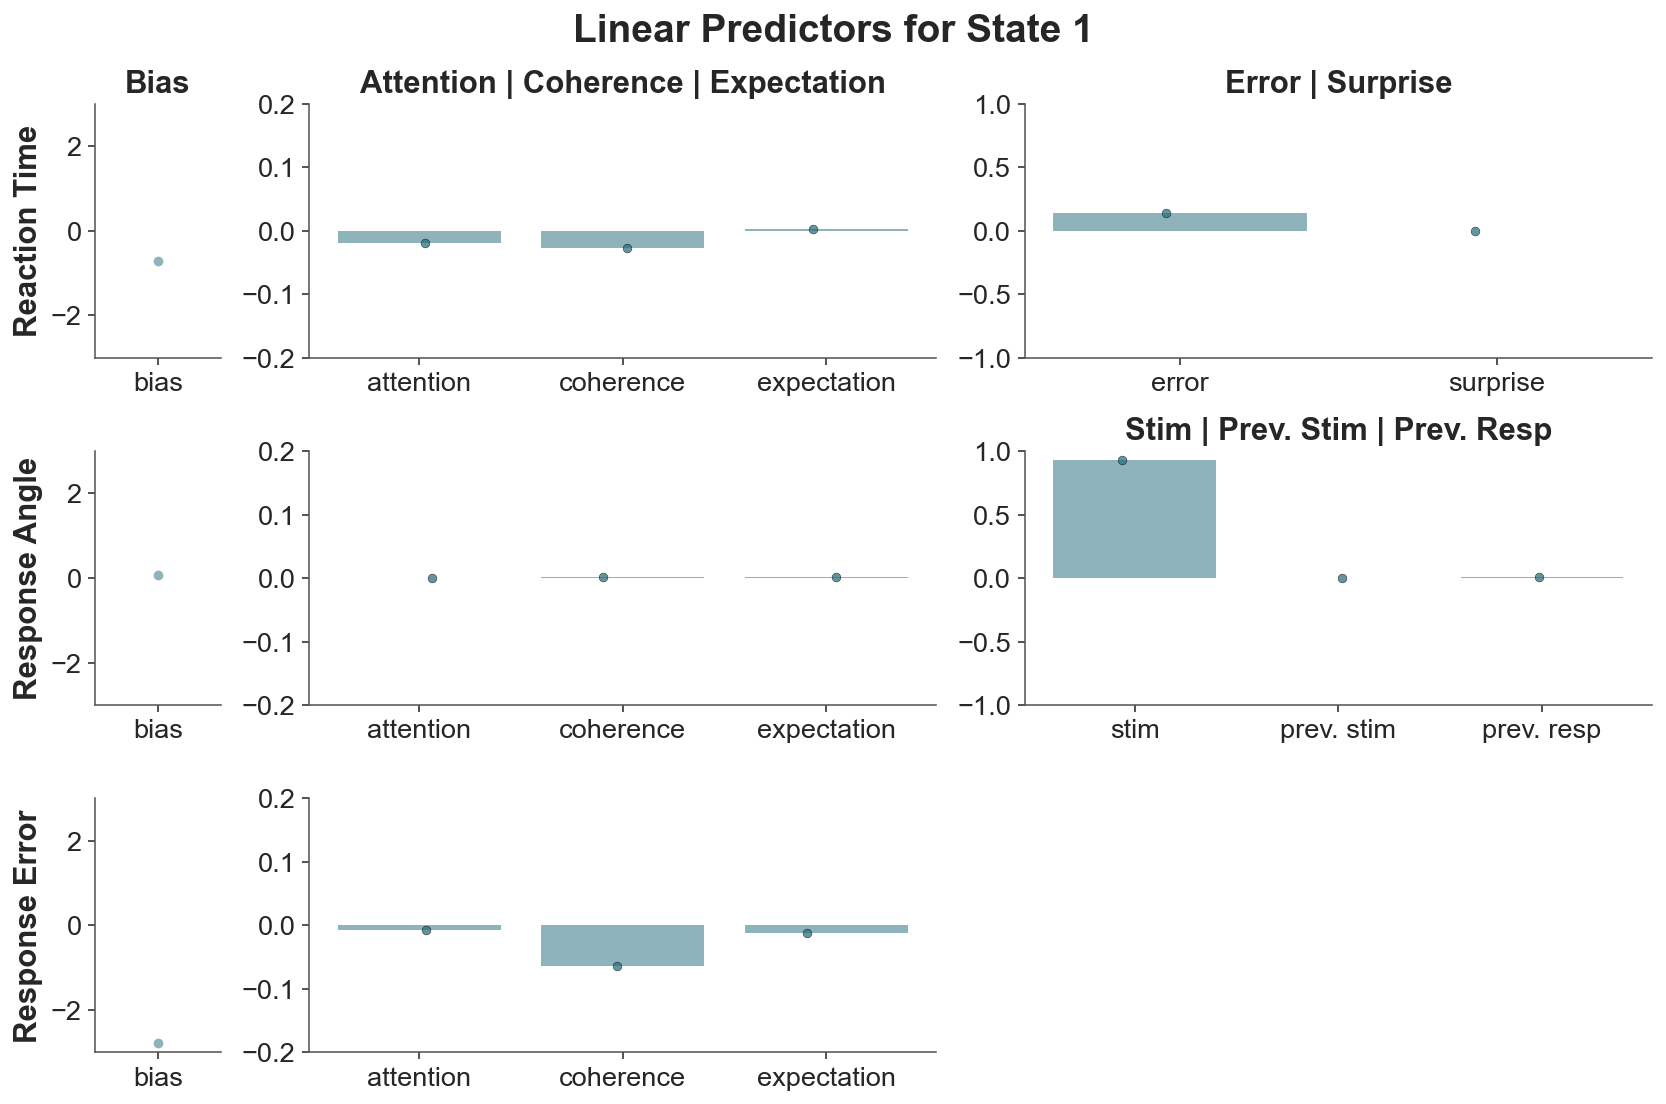

In [92]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

state = 1
jitter_width = 0.1

# data containers
bias_data   = [rt_bias,    ra_bias,    re_bias]
fixed_data  = [rt_fixed,   ra_fixed,   re_fixed]
fixed_labels = ["attention", "coherence", "expectation"]

var_defs = [
    (["error", "surprise"],              [rt_error,    rt_surprise]),
    (["stim", "prev. stim", "prev. resp"], [ra_stim, ra_prev_stim, ra_prev_resp]),
    (None,                                  None),
]

ylabels = ["Reaction Time", "Response Angle", "Response Error"]

fig, ax = plt.subplots(3, 3, figsize=(12, 8), sharey=False, width_ratios=[0.2, 1, 1])


for i in range(3):
    # 1) bias stripplot
    sns.stripplot(
        x=["bias"] * bias_data[i].shape[0],
        y=bias_data[i][:, state],
        color=light_blue, alpha=0.5,
        size=5, jitter=True,
        ax=ax[i, 0]
    )
    ax[i, 0].set_ylabel(ylabels[i], fontsize=16, fontweight="bold")
    ax[i, 0].set_ylim(-3, 3)

    # 2) fixed‑features bar + scatter
    means = fixed_data[i][:, state].mean(axis=0)
    stds  = fixed_data[i][:, state].std(axis=0)
    ax[i, 1].bar(fixed_labels, means, yerr=stds, color=light_blue, alpha=0.5)
    # scatter raw points
    for j, _ in enumerate(fixed_labels):
        vals   = fixed_data[i][:, state, j]
        jitter = np.random.uniform(-jitter_width, jitter_width, size=vals.shape)
        ax[i, 1].scatter(
            j + jitter, vals,
            color=light_blue, alpha=0.7,
            s=20, edgecolor='k', linewidth=0.3
        )
        ax[i, 1].set_ylim(-.2, .2)

    # 3) variable‑features bar + scatter (or hide)
    labels, arrays = var_defs[i]
    if labels is None:
        ax[i, 2].set_visible(False)
    else:
        means = [arr[:, state].mean() for arr in arrays]
        stds  = [arr[:, state].std()  for arr in arrays]
        ax[i, 2].bar(labels, means, yerr=stds, color=light_blue, alpha=0.5)
        for j, arr in enumerate(arrays):
            vals   = arr[:, state]
            jitter = np.random.uniform(-jitter_width, jitter_width, size=vals.shape)
            ax[i, 2].scatter(
                j + jitter, vals,
                color=light_blue, alpha=0.7,
                s=20, edgecolor='k', linewidth=0.3
            )
        ax[i, 2].set_ylim(-1, 1)
        

# column titles
ax[0, 0].set_title("Bias")
ax[0, 1].set_title("Attention | Coherence | Expectation")
ax[0, 2].set_title("Error | Surprise")
ax[1, 2].set_title("Stim | Prev. Stim | Prev. Resp")

plt.suptitle(f"Linear Predictors for State {state}", fontsize=20, fontweight="bold")

plt.tight_layout()
plt.show()


In [43]:
weights.shape, biases.shape, transitions.shape, covs.shape

((12, 2, 3), (12, 2), (12, 2, 2), (12, 2))

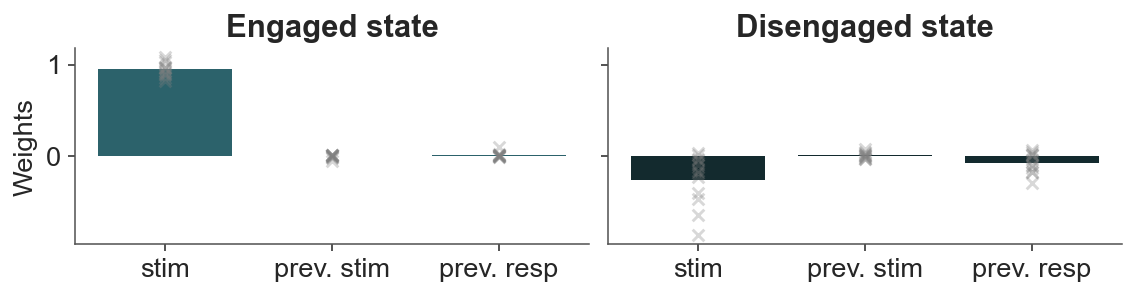

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(8, 2), sharex=True, sharey=True)

# Sns barplot the (12, 2, 3) weights with 12 dots in each and 2 for the 2 plots and 3 for the bars

sns.barplot(x=["stim", "prev. stim", "prev. resp"], y=weights.mean(axis=0)[0], ax=ax[0], color="#216976")
sns.barplot(x=["stim", "prev. stim", "prev. resp"], y=weights.mean(axis=0)[1], ax=ax[1], color="#0e2d33")

# title them engaged and disengaged
ax[0].set_title("Engaged state")
ax[1].set_title("Disengaged state")

# Show the dots for each subject
for i in range(12):
    ax[0].scatter(["stim", "prev. stim", "prev. resp"], weights[i][0], color="gray", alpha=0.3, marker="x")
    ax[1].scatter(["stim", "prev. stim", "prev. resp"], weights[i][1], color="gray", alpha=0.3, marker="x")
    
ax[0].set_ylabel("Weights")
# plt.show()
plt.savefig("weights.svg", format="svg", transparent=True)

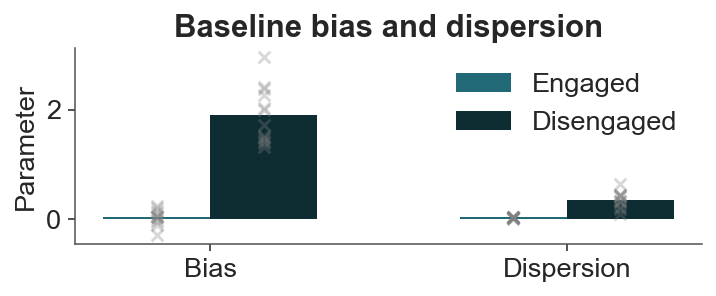

In [45]:
# Define group centers for Bias and Cov on the x-axis.
x_groups = np.array([0, 1])  # 0: Bias, 1: Cov
offset = 0.15  # horizontal offset for the two states

# Set x positions for the two states within each group.
# For Bias: Engaged will be left, Disengaged right.
x_bias_engaged = x_groups[0] - offset
x_bias_disengaged = x_groups[0] + offset
# For Cov: Engaged left, Disengaged right.
x_cov_engaged = x_groups[1] - offset
x_cov_disengaged = x_groups[1] + offset

# Compute mean values for each.
bias_mean = biases.mean(axis=0)  # [Engaged, Disengaged]
cov_mean = covs.mean(axis=0)      # [Engaged, Disengaged]

fig, ax = plt.subplots(figsize=(5,2))

# Plot bars for Bias.
ax.bar(x_bias_engaged, bias_mean[0], width=0.3, color="#216976", label="Engaged")
ax.bar(x_bias_disengaged, bias_mean[1], width=0.3, color="#0e2d33", label="Disengaged")

# Plot bars for Cov.
ax.bar(x_cov_engaged, cov_mean[0], width=0.3, color="#216976")
ax.bar(x_cov_disengaged, cov_mean[1], width=0.3, color="#0e2d33")

# Overlay individual subject data.
for i in range(biases.shape[0]):
    # For Bias.
    ax.scatter(x_bias_engaged, biases[i, 0], color="gray", alpha=0.3, marker="x")
    ax.scatter(x_bias_disengaged, biases[i, 1], color="gray", alpha=0.3, marker="x")
    # For Cov.
    ax.scatter(x_cov_engaged, covs[i, 0], color="gray", alpha=0.3, marker="x")
    ax.scatter(x_cov_disengaged, covs[i, 1], color="gray", alpha=0.3, marker="x")

# Set x-axis ticks and labels for the two groups.
ax.set_xticks(x_groups)
ax.set_xticklabels(["Bias", "Dispersion"])
ax.set_ylabel("Parameter")
ax.set_title("Baseline bias and dispersion")
ax.legend()
# plt.show()
plt.savefig("bias.svg", format="svg", transparent=True)


# State occupancy viz

In [22]:
xaxis = np.arange(-250, 750, 1) * (1000/120)
start_idx, end_idx = np.searchsorted(xaxis, -500), np.searchsorted(xaxis, 1500)
mini_axis = np.arange(120)
(start_idx, end_idx)

(np.int64(191), np.int64(430))

## In general

In [23]:
nstate = 2
idx=9

em, inps = emissions.reshape(12, 4, 6, 120, 1)[idx], inputs.reshape(12, 4, 6, 120, 3)[idx]

em = em.reshape(-1, 120, 1)
inps = inps.reshape(-1, 120, 3)

model = CircularRegressionHMM(nstate, input_dim, emission_dim)
gpar = subject_params[idx][nstate]
parameters, properties = model.initialize(key=jr.PRNGKey(1), 
                                            method="prior",
                                            initial_probs=gpar.initial.probs,
                                            transition_matrix=gpar.transitions.transition_matrix,
                                            emission_weights=gpar.emissions.weights,
                                            emission_biases=gpar.emissions.biases,
                                            emission_covariances=gpar.emissions.covs,)
most_likely_states_vmap = vmap(lambda trial, inp: model.most_likely_states(parameters, trial, inp))
mls = most_likely_states_vmap(em, inps)

In [24]:
mls.shape, em.shape, inps.shape

((24, 120), (24, 120, 1), (24, 120, 3))

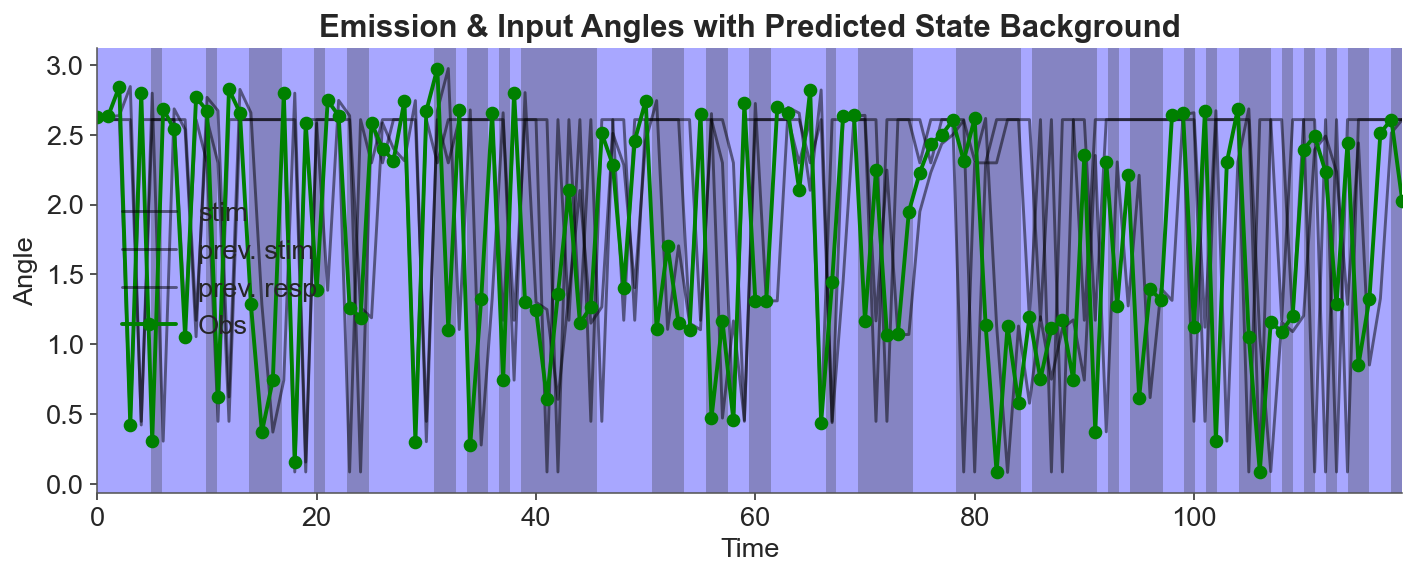

In [25]:
from matplotlib.colors import ListedColormap
# For demonstration, select one sample (index 0)
sample_idx = 0
time = np.arange(120)

em_sample = em[sample_idx, :, 0]
inps_sample = inps[sample_idx]
mls_sample = mls[sample_idx]
all_angles = np.concatenate([em_sample, inps_sample.flatten()])
y_min, y_max = all_angles.min(), all_angles.max()
padding = (y_max - y_min) * 0.05  # add a little extra space
y_min -= padding
y_max += padding
bg = np.tile(mls_sample, (2, 1))  # shape (2, 120)

# Define a colormap for the two states.
# We use the same colors as before: state 0 -> "#9391ff", state 1 -> "#6766b3"
cmap = ListedColormap(["#9391ff", "#6766b3"])

fig, ax = plt.subplots(figsize=(10, 4))

# Plot the background image.
# The 'extent' maps the image to [time_min, time_max] and [y_min, y_max].
ax.imshow(bg, aspect='auto',
          extent=[time[0], time[-1], y_min, y_max],
          origin='lower', cmap=cmap, alpha=0.8)

# Plot the emission angle as a solid line
covs = ['stim', 'prev. stim', 'prev. resp']
# Plot each of the 3 input angles with a dashed line.
for i in range(3):
    ax.plot(time, inps_sample[:, i], '-k', label=f'{covs[i]}', alpha=0.5)

ax.plot(time, em_sample, color='green', label='Obs', linewidth=2, marker="o")

ax.set_xlabel("Time")
ax.set_ylabel("Angle")
ax.set_title("Emission & Input Angles with Predicted State Background")
ax.legend()
plt.show()


/tmp/ipykernel_258812/1819640101.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


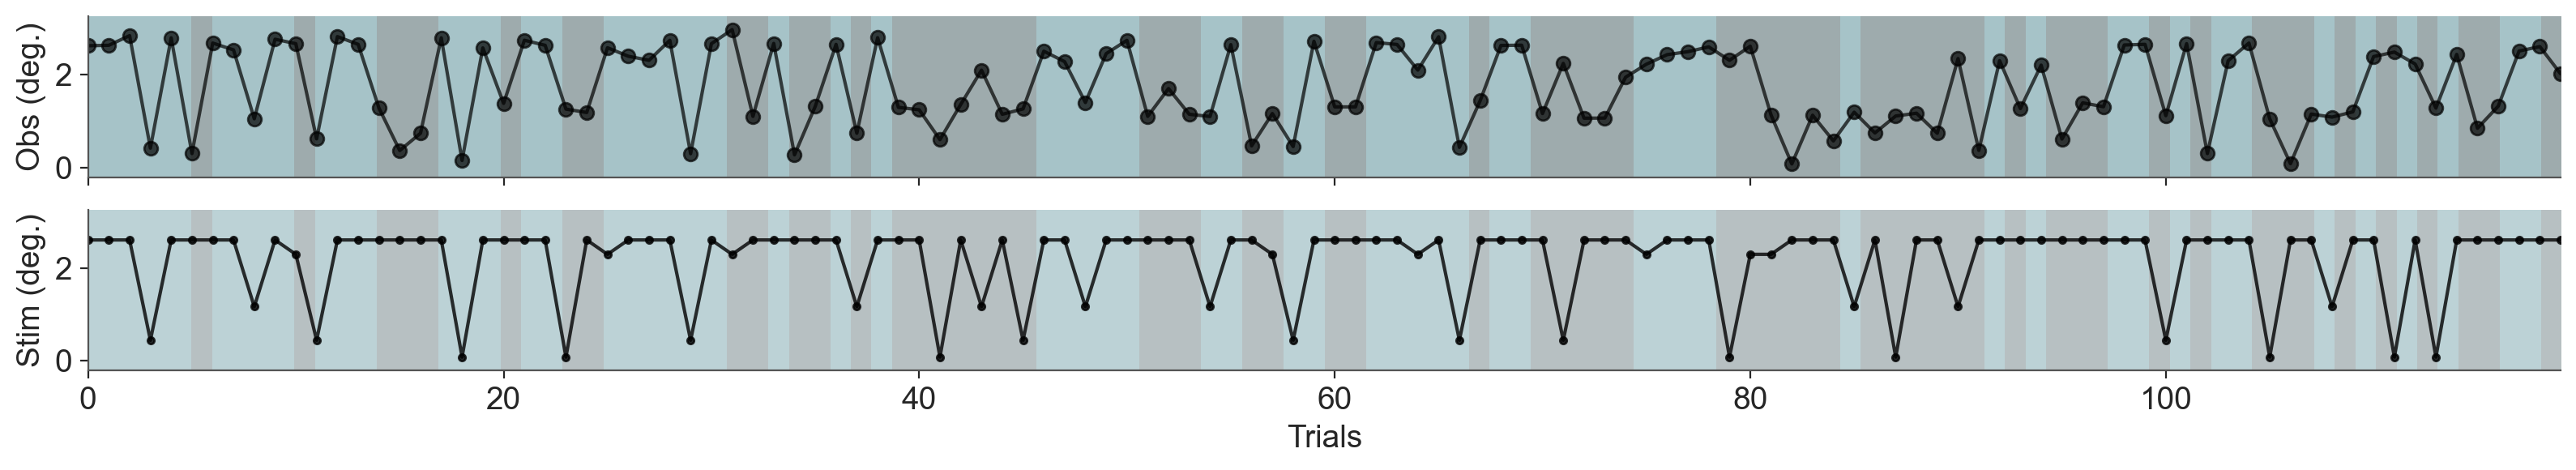

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# For demonstration, select one sample (e.g., sample index 0)
sample_idx = 0
time = np.arange(120)

# Extract the data for the selected sample:
obs_sample = em[sample_idx, :, 0]      # Shape: (120,)
inputs_sample = inps[sample_idx]         # Shape: (120, 3)
states = mls[sample_idx]                 # Shape: (120,)

# Create a 2-row background array by tiling the state vector.
# This will be used with imshow to set the background color per timestep.
bg = np.tile(states, (2, 1))  # Shape: (2, 120)

# Define the colormap for the two states.
# State 0: Engaged -> "#9391ff", State 1: Disengaged -> "#6766b3"
cmap = ListedColormap(["#216976", "#0e2d33"])

# Determine y-axis limits for the observation subplot:
y_min_obs, y_max_obs = obs_sample.min(), obs_sample.max()
padding_obs = (y_max_obs - y_min_obs) * 0.1  # 10% padding
y_min_obs -= padding_obs
y_max_obs += padding_obs

# Determine y-axis limits for the inputs subplot:
y_min_inps, y_max_inps = inputs_sample.min(), inputs_sample.max()
padding_inps = (y_max_inps - y_min_inps) * 0.1
y_min_inps -= padding_inps
y_max_inps += padding_inps

# Create two subplots (top: observations, bottom: inputs)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 3), sharex=True, dpi= 200)
# covs = ['stim', 'prev. stim', 'prev. resp']
covs = ['stim']
# ---- Top subplot: Observations ----
ax1.imshow(bg, aspect='auto',
           extent=[time[0], time[-1], y_min_obs, y_max_obs],
           origin='lower', cmap=cmap, alpha=0.4)
ax1.plot(time, obs_sample, '-ko', label="Observation", alpha=.7)
ax1.set_ylabel("Obs (deg.)")
# ax1.set_title("Observations")
# ax1.legend( loc = "lower right")

# ---- Bottom subplot: Inputs ----
ax2.imshow(bg, aspect='auto',
           extent=[time[0], time[-1], y_min_inps, y_max_inps],
           origin='lower', cmap=cmap, alpha=0.3)
# Plot each of the 3 input angle trajectories
for i in range(1):
    ax2.plot(time, inputs_sample[:, i], '-k.', label=f"{covs[i]}", alpha=0.8)
ax2.set_xlabel("Trials")
ax2.set_ylabel("Stim (deg.)")
# ax2.set_title("Inputs")
# ax2.legend(loc = "lower right")

plt.tight_layout()
# plt.show()
plt.savefig("stim.svg", format="svg", transparent=True)


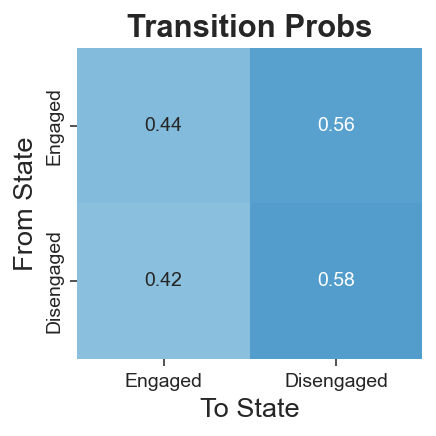

In [27]:
plt.figure(figsize=(3, 3))
sns.heatmap(transitions.mean(axis=0), annot=True, cmap="Blues", cbar=False, vmax=1, vmin=0)

plt.xlabel("To State")
plt.ylabel("From State")
plt.title("Transition Probs")

plt.xticks([.5, 1.5], ["Engaged", "Disengaged"], fontsize=10)
plt.yticks([.5, 1.5], ["Engaged", "Disengaged"], fontsize=10)
plt.show()


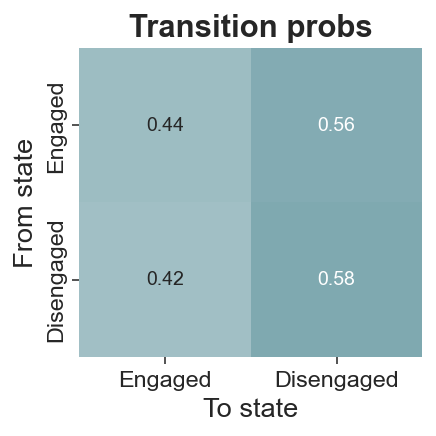

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Create a custom colormap using your colors
my_colors = ["#fff", "#216976"]
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", my_colors)

plt.figure(figsize=(3, 3))
sns.heatmap(transitions.mean(axis=0), annot=True, cmap=custom_cmap,
            cbar=False, vmax=1, vmin=0)

plt.xlabel("To state")
plt.ylabel("From state")
plt.title("Transition probs")

plt.xticks([.5, 1.5], ["Engaged", "Disengaged"], fontsize=12)
plt.yticks([.5, 1.5], ["Engaged", "Disengaged"], fontsize=12)
# plt.show()
plt.savefig("trans.svg", format="svg", transparent=True)


In [29]:
weights[0]

array([[ 0.8567895 ,  0.01327817,  0.0185459 ],
       [-0.40152428,  0.08255423, -0.28946513]], dtype=float32)

## By condition fits

In [30]:
ml_concat = {}

for cond in ml_states.keys():
    cc = []
    for subject in ml_states[cond].keys():
        cc.append(ml_states[cond][subject])
    ml_concat[cond] = np.concatenate(cc, axis=0)

In [31]:
def plot_occ(ld, hd, low_name, high_name, effect, subject = None, ax = None):
    state_probs = {state: np.mean(ld == state, axis=0) for state in [0, 1]}
    for state, probs in state_probs.items():
        ax.plot(mini_axis, probs, label=[f"{low_name} accumulation", f"{low_name} decision"][state], linewidth=3, color=light_cols[state])

    state_probs = {state: np.mean(hd == state, axis=0) for state in [0, 1]}
    for state, probs in state_probs.items():
        ax.plot(mini_axis, probs, label=[f"{high_name} accumulation", f"{high_name} decision"][state], linewidth=3, color=dark_cols[state])


    # plt.ylim(0, 1)
    # ax.set_xlim(-500, 1500)
    # ax.set_ylim(0, 1)

    if subject: ax.set_title(f'{subject}')
    ax.set_xlabel('Time from onset (ms)')
    ax.set_ylabel('p(state)')
    # ax.legend()

    handles, labels = ax.get_legend_handles_labels()
    order = [0,2,1,3]
    ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc='center left')

    ax.grid(True)
    # plt.show()

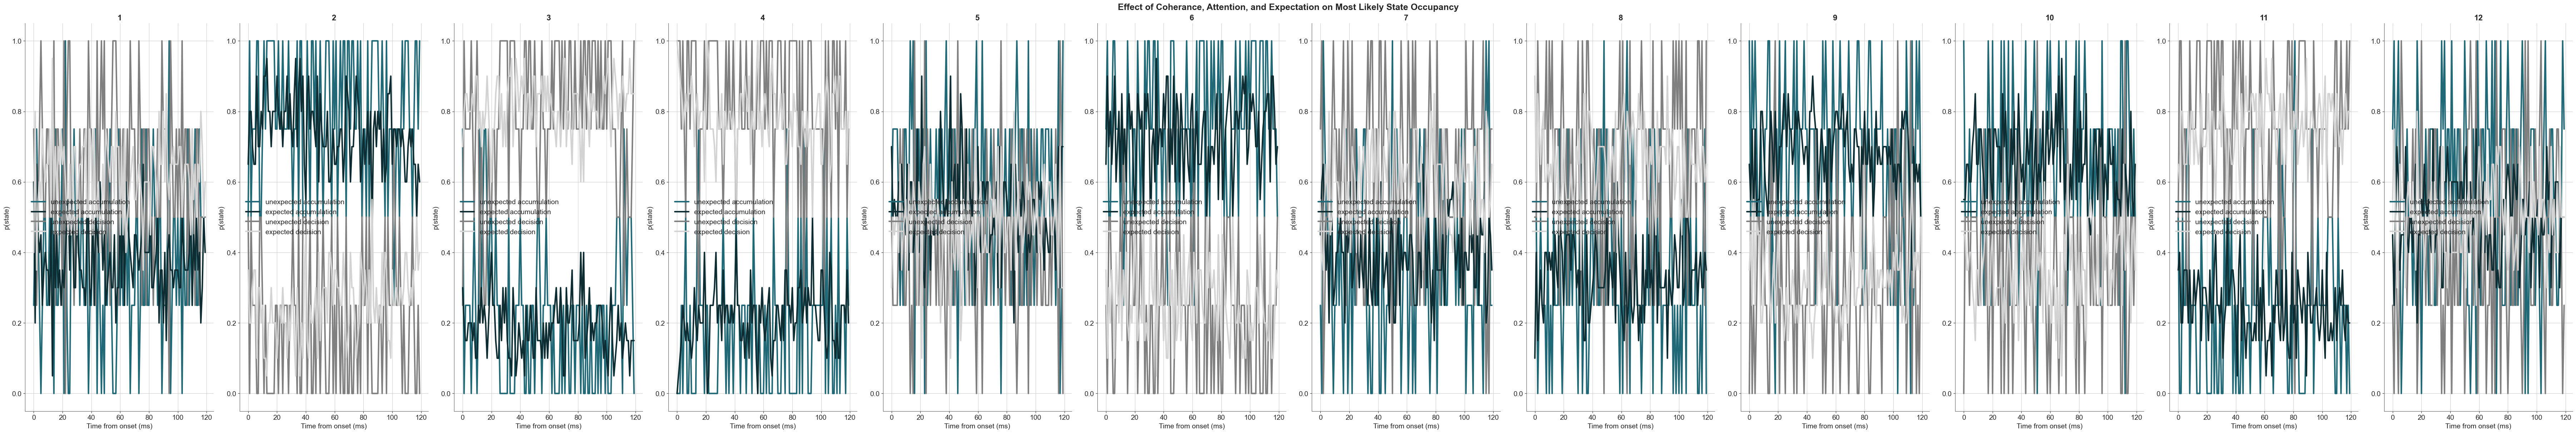

In [ ]:
fig, axs = plt.subplots(1, 12, figsize=(6*12, 4*3), dpi=100)

for idx in range(12):
    subject = idx
    a = np.array(ml_states["unexpected"][subject])
    b = np.array(ml_states["expected"][subject])

    plot_occ(a, b, "unexpected", "expected", "Expectation", subject + 1, ax = axs.flatten()[idx])

plt.suptitle(f"Effect of Coherence, Attention, and Expectation on Most Likely State Occupancy")
plt.show()

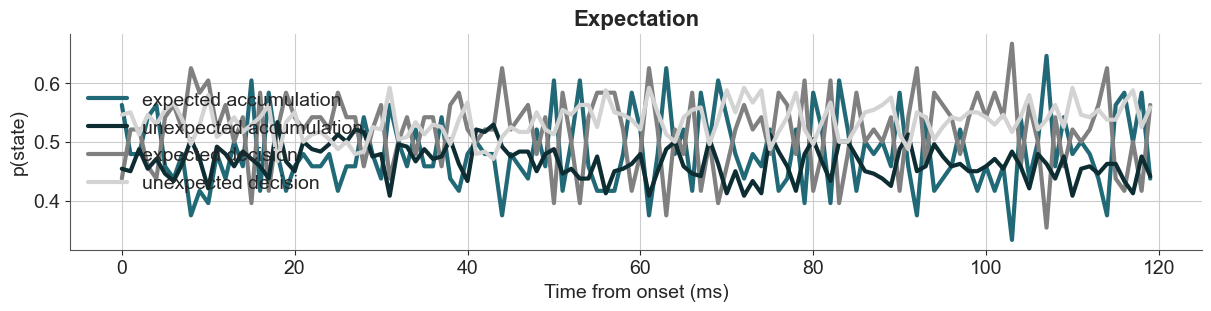

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(12, 3), dpi=100)

a = np.array(ml_concat["unexpected"])
b = np.array(ml_concat["expected"])

plot_occ(a, b, "expected", "unexpected", "Expectation", "Expectation", ax = axs)

# plt.suptitle(f"Effect of coherence, Attention, and Expectation on Most Likely State Occupancy")
plt.show()

In [34]:
st = 2
sb = 9
ts = subject_params[sb][st]
model = CircularRegressionHMM(st, input_dim, emission_dim)

In [35]:
mls = []
for e, i in zip(emissions.reshape(12, 4 * 6, 120, 1)[sb], inputs.reshape(12, 4 * 6, 120, 3)[sb]):
    most_likely_states = model.most_likely_states(ts, e, inputs=i)
    mls.append(most_likely_states)
    
mls = np.array(mls)

In [36]:
# Count occurrences for each class (assuming classes 0, 1, 2)
counts = np.bincount(mls.flatten(), minlength=st)
proportions = counts / mls.size  # mls.size is 2880 in this case

print("Overall proportions:", proportions)

Overall proportions: [0.65104167 0.34895833]


<Axes: >

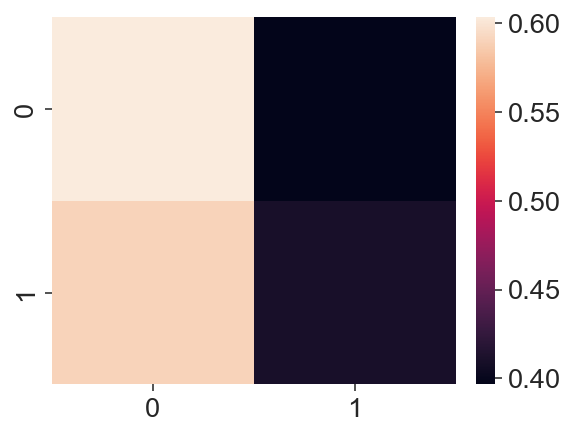

In [37]:
plt.figure(figsize=(4,3))
sns.heatmap(ts.transitions.transition_matrix)

In [38]:
ts.emissions

ParamsCircularRegressionHMMEmissions(weights=Array([[[ 0.89984286,  0.01340821, -0.00095838]],

       [[-0.1577232 ,  0.01794599,  0.07270677]]], dtype=float32), biases=Array([[0.05487401],
       [1.3948828 ]], dtype=float32), covs=Array([[[0.02789198]],

       [[0.41059804]]], dtype=float32))